Data Quality Assessment

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

feature_df = pd.read_csv("parkinson_features.csv")

feature_df.head()

,data_file_name,updrs,age,gender,patient_off_on,speed,amplitude,hesitation,halt,decrement
0,raw_data_af753f25-2ce9-11ed-b9a2-e82aea2c97f4.csv,3,70,Male,off,1.690406,0.102263,0.064616,0.735381,-0.001022
1,raw_data_50a1a7ef-b3e9-11ec-82ad-e82aea2c97f4.csv,1,52,Male,off,1.147201,0.142738,0.147240,0.999191,-0.000665
2,raw_data_a2c7fb0f-2f67-11ed-8b72-e82aea2c97f4.csv,2,66,Female,on,2.677253,0.046984,0.042792,0.463064,0.000006
3,raw_data_80c83c65-e86c-11ec-8d35-fd71ae554d63.csv,2,63,Female,off,4.876620,0.051611,0.116886,0.830335,-0.000287
4,raw_data_cfa563e1-2205-11ed-a68f-b469216ca443.csv,3,23,Male,off,1.421498,0.077387,0.054981,0.799055,-0.000876


In [4]:
print("="*60)
print("DATASET INFORMATION")
print("="*60)

print(feature_df.info())

print("\nShape:", feature_df.shape)

print("\nColumns:")
print(feature_df.columns.tolist())

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   data_file_name  195 non-null    str    
 1   updrs           195 non-null    int64  
 2   age             195 non-null    int64  
 3   gender          195 non-null    str    
 4   patient_off_on  195 non-null    str    
 5   speed           195 non-null    float64
 6   amplitude       195 non-null    float64
 7   hesitation      195 non-null    float64
 8   halt            195 non-null    float64
 9   decrement       195 non-null    float64
dtypes: float64(5), int64(2), str(3)
memory usage: 15.4 KB
None

Shape: (195, 10)

Columns:
['data_file_name', 'updrs', 'age', 'gender', 'patient_off_on', 'speed', 'amplitude', 'hesitation', 'halt', 'decrement']


In [5]:
missing = feature_df.isnull().sum()

missing = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing/len(feature_df))*100
})

print(missing)

                Missing Values  Percentage
data_file_name               0         0.0
updrs                        0         0.0
age                          0         0.0
gender                       0         0.0
patient_off_on               0         0.0
speed                        0         0.0
amplitude                    0         0.0
hesitation                   0         0.0
halt                         0         0.0
decrement                    0         0.0


In [6]:
duplicates = feature_df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [7]:
summary = feature_df.describe()

summary

,updrs,age,speed,amplitude,hesitation,halt,decrement
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,2.194872,54.661538,2.498512,0.068543,0.178472,0.951391,-0.000346
std,1.011773,21.644940,1.110205,0.030589,0.286749,0.826983,0.001299
min,0.000000,0.000000,0.339994,0.022702,0.023521,0.304553,-0.015362
25%,2.000000,32.500000,1.731501,0.047195,0.061717,0.530946,-0.000553
50%,2.000000,64.000000,2.287265,0.063207,0.093345,0.706947,-0.000247
75%,3.000000,70.000000,3.192340,0.083790,0.170557,0.947395,0.000013
max,4.000000,83.000000,7.058567,0.244167,2.334048,5.719185,0.003257


Distribution Analysis

1.Speed

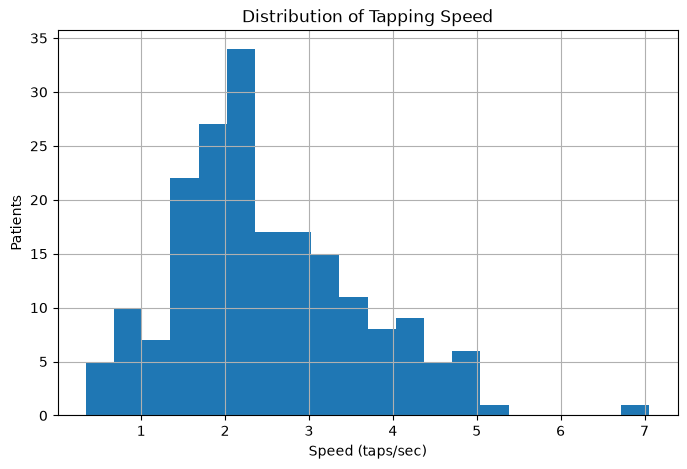

In [8]:
plt.figure(figsize=(8,5))

plt.hist(feature_df["speed"], bins=20)

plt.title("Distribution of Tapping Speed")

plt.xlabel("Speed (taps/sec)")

plt.ylabel("Patients")

plt.grid(True)

plt.show()

2.Amplitude

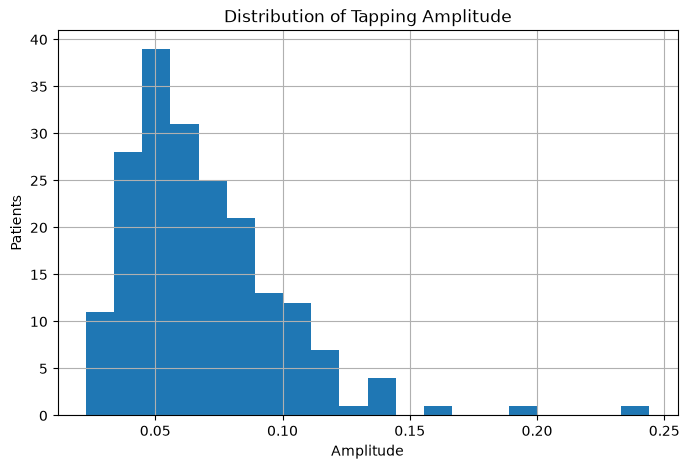

In [9]:
plt.figure(figsize=(8,5))

plt.hist(feature_df["amplitude"], bins=20)

plt.title("Distribution of Tapping Amplitude")

plt.xlabel("Amplitude")

plt.ylabel("Patients")

plt.grid(True)

plt.show()

3.Hesitation

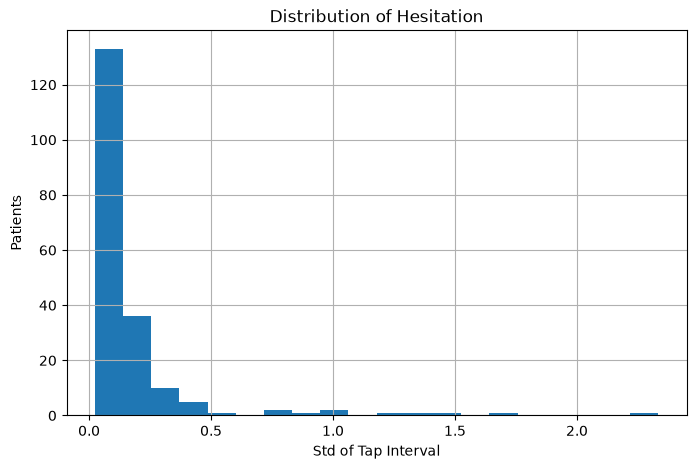

In [10]:
plt.figure(figsize=(8,5))

plt.hist(feature_df["hesitation"], bins=20)

plt.title("Distribution of Hesitation")

plt.xlabel("Std of Tap Interval")

plt.ylabel("Patients")

plt.grid(True)

plt.show()

4.Halt

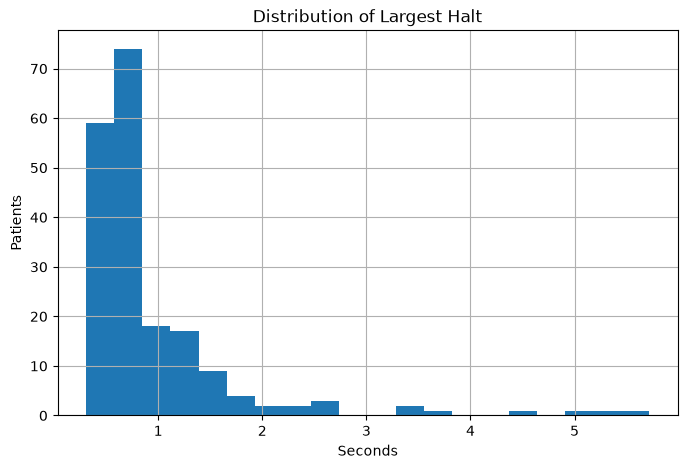

In [11]:
plt.figure(figsize=(8,5))

plt.hist(feature_df["halt"], bins=20)

plt.title("Distribution of Largest Halt")

plt.xlabel("Seconds")

plt.ylabel("Patients")

plt.grid(True)

plt.show()

5.Decrement

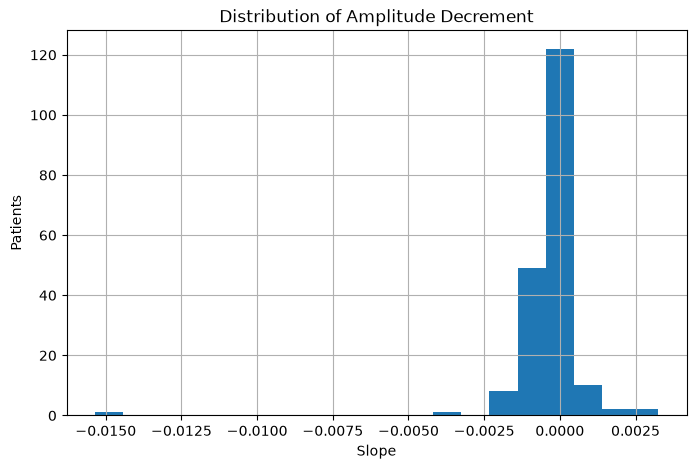

In [12]:
plt.figure(figsize=(8,5))

plt.hist(feature_df["decrement"], bins=20)

plt.title("Distribution of Amplitude Decrement")

plt.xlabel("Slope")

plt.ylabel("Patients")

plt.grid(True)

plt.show()

Feature vs UPDRS

1.Speed

<Figure size 800x500 with 0 Axes>

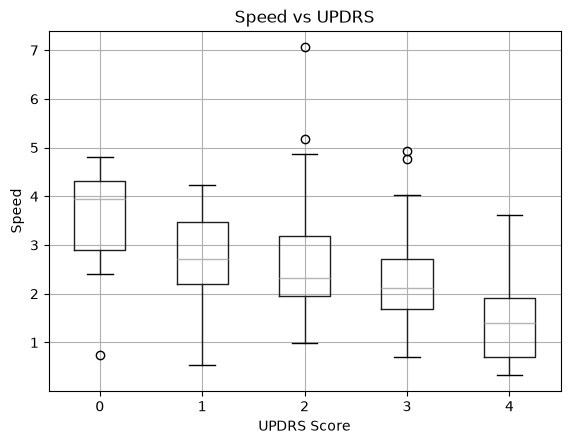

In [13]:
plt.figure(figsize=(8,5))

feature_df.boxplot(
    column="speed",
    by="updrs"
)

plt.title("Speed vs UPDRS")

plt.suptitle("")

plt.xlabel("UPDRS Score")

plt.ylabel("Speed")

plt.show()

2.Amplitude

<Figure size 800x500 with 0 Axes>

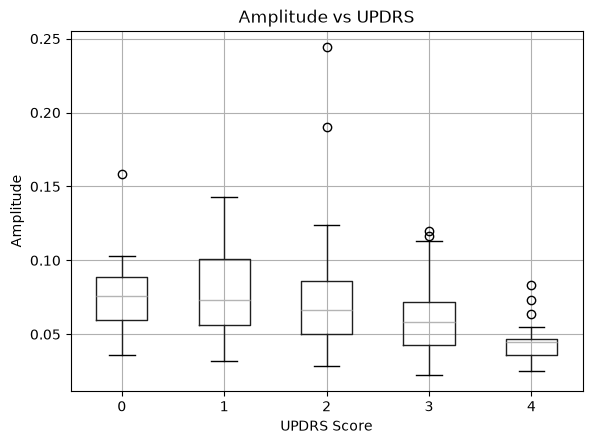

In [14]:
plt.figure(figsize=(8,5))

feature_df.boxplot(
    column="amplitude",
    by="updrs"
)

plt.title("Amplitude vs UPDRS")

plt.suptitle("")

plt.xlabel("UPDRS Score")

plt.ylabel("Amplitude")

plt.show()

3.Hesitation

<Figure size 800x500 with 0 Axes>

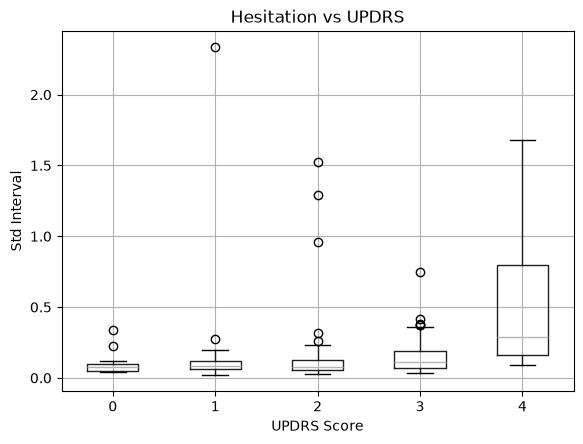

In [15]:
plt.figure(figsize=(8,5))

feature_df.boxplot(
    column="hesitation",
    by="updrs"
)

plt.title("Hesitation vs UPDRS")

plt.suptitle("")

plt.xlabel("UPDRS Score")

plt.ylabel("Std Interval")

plt.show()

4.Halt

<Figure size 800x500 with 0 Axes>

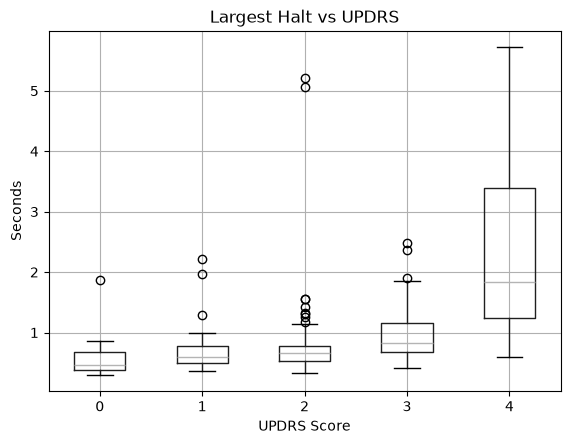

In [16]:
plt.figure(figsize=(8,5))

feature_df.boxplot(
    column="halt",
    by="updrs"
)

plt.title("Largest Halt vs UPDRS")

plt.suptitle("")

plt.xlabel("UPDRS Score")

plt.ylabel("Seconds")

plt.show()

5.Decrement

<Figure size 800x500 with 0 Axes>

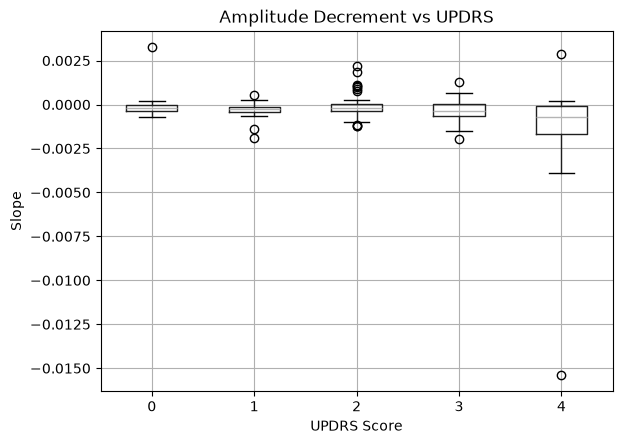

In [17]:
plt.figure(figsize=(8,5))

feature_df.boxplot(
    column="decrement",
    by="updrs"
)

plt.title("Amplitude Decrement vs UPDRS")

plt.suptitle("")

plt.xlabel("UPDRS Score")

plt.ylabel("Slope")

plt.show()

Correlation Analysis

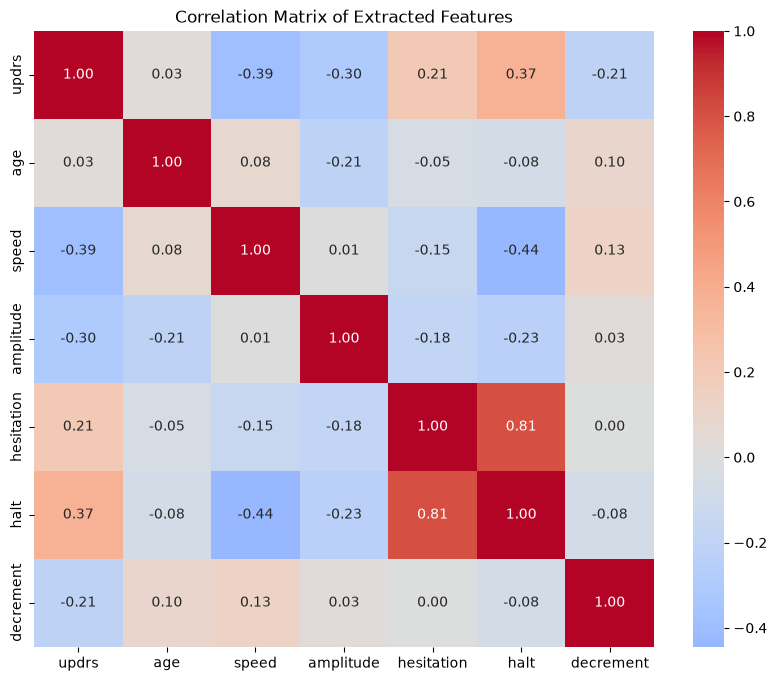

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = feature_df.select_dtypes(include=["number"])

# Correlation matrix
corr = numeric_df.corr(method="pearson")

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix of Extracted Features")

plt.show()

Statistical Significance

In [ ]:
#Shapiro-Wilk Normality Test
from scipy.stats import shapiro

features = [
    "speed",
    "amplitude",
    "hesitation",
    "halt",
    "decrement"
]

for feature in features:

    stat, p = shapiro(feature_df[feature])

    print(f"{feature}")

    print(f"Statistic = {stat:.4f}")

    print(f"P-value = {p:.4f}")

    if p > 0.05:
        print("Normally Distributed\n")
    else:
        print("Not Normally Distributed\n")

speed
Statistic = 0.9685
P-value = 0.0002
Not Normally Distributed

amplitude
Statistic = 0.8913
P-value = 0.0000
Not Normally Distributed

hesitation
Statistic = 0.4557
P-value = 0.0000
Not Normally Distributed

halt
Statistic = 0.6021
P-value = 0.0000
Not Normally Distributed

decrement
Statistic = 0.4543
P-value = 0.0000
Not Normally Distributed



In [20]:
#Kruskal-Wallis
from scipy.stats import kruskal

features = [
    "speed",
    "amplitude",
    "hesitation",
    "halt",
    "decrement"
]

for feature in features:

    groups = [
        group[feature].values
        for _, group in feature_df.groupby("updrs")
    ]

    stat, p = kruskal(*groups)

    print(f"{feature}")

    print(f"H = {stat:.3f}")

    print(f"P = {p:.5f}")

    print()

speed
H = 33.897
P = 0.00000

amplitude
H = 24.934
P = 0.00005

hesitation
H = 35.508
P = 0.00000

halt
H = 47.200
P = 0.00000

decrement
H = 8.421
P = 0.07733

